# Basic Reflection Agent With LangChain for Trading Strategies Python Code Implementation

Mounted at /content/drive


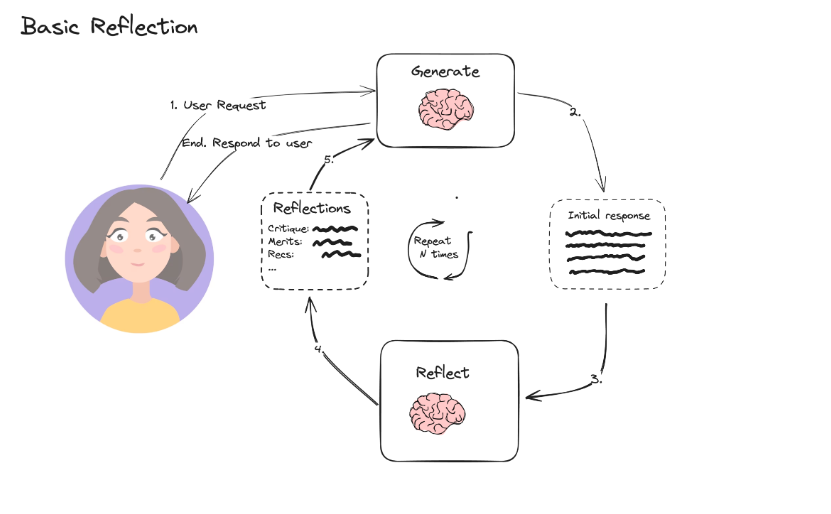

In [ ]:
from PIL import Image
from IPython.display import display
img = Image.open(local_path+'basic_reflection.png')
display(img)

# Steps

Here are the different steps of a **basic Reflection**:

**Generator**:
1.   The Generator LLM answers to a given query. `*Prompt_generator* = Propose a Python code implemtation for a trading strategy`


**Reflection**
2.   The Reflection LLM will evaluate the ouput of the Generator.`*Prompt_reflector* = Evalute the Python code implementation generated by the Generator.`

**Review**
3.   With the first implementation and the reflection (feedback), LLM (generator) will make the correction for the Python code implementation.
*You have below one call example and A loop example.*



In [ ]:
!pip install -U --quiet  langchain
!pip install --quiet langchain_openai

In [ ]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [ ]:
from langchain_openai import ChatOpenAI

from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0, api_key=OPENAI_API_KEY)

# Initial Generate

### Prompt generate

In [ ]:
prompt_generate = """You are a Python code generator specializing in algorithmic trading. Your main role is to provide Python code solutions that are straightforward, efficient, and strictly follow Pythonic principles. Your responses should strictly consist of executable Python code tailored to algorithmic trading strategies.
Please adhere to these protocols:
- Generate a code that is simple, efficient, optimized and the most understandable possible.
- Augment your code by inline comments and docstrings, when it's necessary, to clarify the functionality and the structure of the code.
- Make sure all code conforms to Python best practices and conventions.
- This code will be used as it is by the user, so make sure to generate an executable code in prodution environment.
- Only produce executable Python code. Omit any explanatory text, descriptions, or elements that are not code from your responses.
- Avoid using non-existent built-in methods, such as np.rolling or pd.rolling, in well-known libraries.

Answer only with Pyton code without any explanatory text, descriptions, or elements that are not code from your responses.
"""

### Generator

In [ ]:
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
           prompt_generate,
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

generate = prompt | llm

In [ ]:
stratgies = ['MACD', 'RSI', "Stochastic oscillator"]

### Run Generator on a query [request]

I choose here the RSI (which is a little bit challenging for a Python code generaion)

In [ ]:
strat_trd = stratgies[1]
query = f"Give me a Python code implementation of the {strat_trd}"

request = HumanMessage(
    content = query
)

# response = generate.invoke({"messages": [request]})
# code = response.content
# print(code)

code = ""
for chunk in generate.stream({"messages": [request]}):
    print(chunk.content, end="")
    code += chunk.content

```python
def calculate_rsi(prices, n=14):
    """
    Calculate the Relative Strength Index (RSI) of a given price series.
    
    Parameters:
    prices (list): List of prices.
    n (int): Number of periods to consider for RSI calculation.
    
    Returns:
    float: RSI value.
    """
    deltas = [prices[i + 1] - prices[i] for i in range(len(prices) - 1)]
    gain = [d if d > 0 else 0 for d in deltas]
    loss = [-d if d < 0 else 0 for d in deltas]
    
    avg_gain = sum(gain[:n]) / n
    avg_loss = sum(loss[:n]) / n
    
    for i in range(n, len(prices) - 1):
        avg_gain = (avg_gain * (n - 1) + gain[i]) / n
        avg_loss = (avg_loss * (n - 1) + loss[i]) / n
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi
```

# Reflection

### Prompt reflection

In [ ]:
prompt_reflection = """You are tasked with evaluating Python code for algorithmic trading. Here are your responsibilities:
- Assess the code's readability, check for bugs, and ensure there's adequate documentation. Provide specific feedback on areas needing correction or simplification.
- Ensure the code is well-structured into modules and functions, with each performing a single responsibility. Functions and classes should be concise and focused. Offer suggestions for areas needing clarity or reorganization.
- Check compliance with PEP 8 guidelines, including appropriate use of whitespace, line length, and indentation. Identify any parts that require modification.
- Review the implemented logic to confirm there are no algorithmic errors. Pay close attention to typical issues such as off-by-one errors or incorrect condition checks.
- Verify that all functions, classes, and modules have comprehensive docstrings explaining their purpose, parameters, and returns. Only provide feedback if modifications are needed.
- Evaluate the code’s efficiency, particularly in data manipulation and mathematical computations. Identify any unnecessary computations or inefficient data structures and suggest improvements.
- Refrain from using non-existent built-in methods in well-known libraries.
Your Feedback Protocol:
- If suggesting modifications, include the specific code segment and your recommendations.
- If no suggestions are necessary, respond with only the relevant Python code, omitting any explanatory text or descriptions.
"""

### Reflect LLM

In [ ]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            prompt_reflection,
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

reflect = reflection_prompt | llm

### Run reflect LLM on [request, previously generated code]

In [ ]:
reflection = ""
for chunk in reflect.stream({"messages": [request, HumanMessage(content=code)]}):
    print(chunk.content, end="")
    reflection += chunk.content

- The calculation of RSI seems to have a bug in the loop where it updates `avg_gain` and `avg_loss`. The loop should iterate until `len(prices)` instead of `len(prices) - 1`.
- The loop should start from `n` instead of `n` to consider the correct range for updating `avg_gain` and `avg_loss`.
- The calculation of `rs` and `rsi` should be done after the loop to ensure the correct values are used.
- The function lacks input validation to handle cases where the length of `prices` is less than `n+1`.
- The function could benefit from more descriptive variable names for better readability.

Here is the revised code incorporating the above suggestions:

```python
def calculate_rsi(prices, n=14):
    """
    Calculate the Relative Strength Index (RSI) of a given price series.
    
    Parameters:
    prices (list): List of prices.
    n (int): Number of periods to consider for RSI calculation.
    
    Returns:
    float: RSI value.
    """
    if len(prices) < n + 1:
        raise ValueError(

In [ ]:
# # or without streaming:
# resp = reflect.invoke({"messages": [request, HumanMessage(content=code)]})
# print(resp.content)

# Review

`Based on the first code implementation proposition from the Generetaor + the feedback from the reflection: Generate a new python code implementation`

#### One call

In [ ]:
review = ""
for chunk in generate.stream(
    {"messages": [request, AIMessage(content=code), HumanMessage(content=reflection)]}
):
    print(chunk.content, end="")
    review +=chunk.content

```python
def calculate_rsi(prices, n=14):
    """
    Calculate the Relative Strength Index (RSI) of a given price series.
    
    Parameters:
    prices (list): List of prices.
    n (int): Number of periods to consider for RSI calculation.
    
    Returns:
    float: RSI value.
    """
    if len(prices) < n + 1:
        raise ValueError("Number of prices should be greater than n+1 for RSI calculation.")
    
    deltas = [prices[i + 1] - prices[i] for i in range(len(prices) - 1)]
    gain = [d if d > 0 else 0 for d in deltas]
    loss = [-d if d < 0 else 0 for d in deltas]
    
    avg_gain = sum(gain[:n]) / n
    avg_loss = sum(loss[:n]) / n
    
    for i in range(n, len(prices)):
        avg_gain = (avg_gain * (n - 1) + gain[i]) / n
        avg_loss = (avg_loss * (n - 1) + loss[i]) / n
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi
```

In [ ]:
# END = ""
# for chunk in generate.stream(
#     {"messages": [request, AIMessage(content=code), HumanMessage(content=reflection)]}
# ):
#     print(chunk.content, end="")
#     END +=chunk.content

#### Loop

In [ ]:
#3 iterations
for i in range(0,3):
  print("Generator with feedback from Reflection")
  corrector = ""
  for chunk in generate.stream(
      {"messages": [request, AIMessage(content=reflection), HumanMessage(content=review)]}
  ):
      print(chunk.content, end="")
      corrector +=chunk.content

  review = corrector

  print("\n")
  print("*"*50)
  print("\nReflection")
  reflection = ""
  for chunk in reflect.stream({"messages": [request, HumanMessage(content=corrector)]}):
      print(chunk.content, end="")
      reflection += chunk.content
  print("*"*50)

Generator with feedback from Reflection
The provided code for calculating the Relative Strength Index (RSI) looks correct and well-structured. It includes input validation, variable initialization, and the iterative calculation of RSI components. This function should work effectively for computing the RSI value based on the given price series and the specified number of periods.

If you have any specific questions or need further assistance with this code, feel free to ask!

**************************************************

Reflection
```python
def calculate_rsi(prices, n=14):
    """
    Calculate the Relative Strength Index (RSI) for a given price series.

    Args:
    prices (list): List of prices.
    n (int): Number of periods for RSI calculation (default is 14).

    Returns:
    float: The RSI value.
    """
    if len(prices) < 2:
        raise ValueError("Input prices list must have at least 2 elements")

    deltas = [prices[i] - prices[i - 1] for i in range(1, len(prices)

### Final Code

In [ ]:
print(reflection)

```python
def calculate_rsi(prices, n=14):
    """
    Calculate the Relative Strength Index (RSI) for a given list of prices.

    :param prices: List of prices
    :param n: Number of periods to consider for RSI calculation (default is 14)
    :return: List of RSI values
    """
    deltas = np.diff(prices)
    seed = deltas[:n+1]
    up = seed[seed >= 0].sum() / n
    down = -seed[seed < 0].sum() / n
    rs = up / down
    rsi = np.zeros_like(prices)
    rsi[:n] = 100. - 100. / (1. + rs)

    for i in range(n, len(prices)):
        delta = deltas[i - 1]

        if delta > 0:
            upval = delta
            downval = 0.
        else:
            upval = 0.
            downval = -delta

        up = (up * (n - 1) + upval) / n
        down = (down * (n - 1) + downval) / n

        rs = up / down
        rsi[i] = 100. - 100. / (1. + rs)

    return rsi
```


# The whole process

In [ ]:
stratgies = ['MACD', 'RSI', "Stochastic oscillator"]

## Generator and Reflection Agents

In [ ]:
prompt_generate = """You are a Python code generator specializing in algorithmic trading. Your main role is to provide Python code solutions that are straightforward, efficient, and strictly follow Pythonic principles. Your responses should strictly consist of executable Python code tailored to algorithmic trading strategies.
Please adhere to these protocols:
- Generate a code that is simple, efficient, optimized and the most understandable possible.
- Augment your code by inline comments and docstrings, when it's necessary, to clarify the functionality and the structure of the code.
- Make sure all code conforms to Python best practices and conventions.
- This code will be used as it is by the user, so make sure to generate an executable code in prodution environment.
- Only produce executable Python code. Omit any explanatory text, descriptions, or elements that are not code from your responses.
- Avoid using non-existent built-in methods, such as np.rolling or pd.rolling, in well-known libraries.

Answer only with Pyton code without any explanatory text, descriptions, or elements that are not code from your responses.
"""

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
           prompt_generate,

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

generate = prompt | llm


prompt_reflection = """You are tasked with evaluating Python code for algorithmic trading. Here are your responsibilities:
- Assess the code's readability, check for bugs, and ensure there's adequate documentation. Provide specific feedback on areas needing correction or simplification.
- Ensure the code is well-structured into modules and functions, with each performing a single responsibility. Functions and classes should be concise and focused. Offer suggestions for areas needing clarity or reorganization.
- Check compliance with PEP 8 guidelines, including appropriate use of whitespace, line length, and indentation. Identify any parts that require modification.
- Review the implemented logic to confirm there are no algorithmic errors. Pay close attention to typical issues such as off-by-one errors or incorrect condition checks.
- Verify that all functions, classes, and modules have comprehensive docstrings explaining their purpose, parameters, and returns. Only provide feedback if modifications are needed.
- Evaluate the code’s efficiency, particularly in data manipulation and mathematical computations. Identify any unnecessary computations or inefficient data structures and suggest improvements.
- Refrain from using non-existent built-in methods in well-known libraries.
Your Feedback Protocol:
- If suggesting modifications, include the specific code segment and your recommendations.
- If no suggestions are necessary, respond with only the relevant Python code, omitting any explanatory text or descriptions.
"""


reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (


            "system",
            prompt_reflection,
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

reflect = reflection_prompt | llm


## Loop Generator + Reflection: RSI

In [ ]:
strat_trd = stratgies[1]
query = f"Give me a Python code implementation of the {strat_trd}"

request = HumanMessage(
    content = query
)

code = ""
for chunk in generate.stream({"messages": [request]}):
    print(chunk.content, end="")
    code += chunk.content


#3 iterations
for i in range(0,3):

  print("\nReflection")
  reflection = ""
  for chunk in reflect.stream({"messages": [request, HumanMessage(content=code)]}):
      print(chunk.content, end="")
      reflection += chunk.content

  print("\n")
  print("*"*50)
  print("Generator with feedback from Reflection")
  corrector = ""
  for chunk in generate.stream(
      {"messages": [request, AIMessage(content=code), HumanMessage(content=reflection)]}
  ):
      print(chunk.content, end="")
      corrector +=chunk.content

  code = corrector
  print("*"*50)

```python
def calculate_rsi(prices, n=14):
    """
    Calculate the Relative Strength Index (RSI) for a given list of prices.

    Parameters:
    prices (list): List of prices.
    n (int): Number of periods to consider for RSI calculation.

    Returns:
    float: The Relative Strength Index (RSI) value.
    """
    deltas = [prices[i + 1] - prices[i] for i in range(len(prices) - 1)]
    gain = [delta if delta > 0 else 0 for delta in deltas]
    loss = [-delta if delta < 0 else 0 for delta in deltas]

    avg_gain = sum(gain[:n]) / n
    avg_loss = sum(loss[:n]) / n

    for i in range(n, len(prices) - 1):
        avg_gain = (avg_gain * (n - 1) + gain[i]) / n
        avg_loss = (avg_loss * (n - 1) + loss[i]) / n

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi
```
Reflection
- The code implementation of RSI looks good in terms of logic and readability.
- It follows the PEP 8 guidelines.
- The function `calculate_rsi` is well-documented with clear explan

## Loop Generator + Reflection: MACD

In [ ]:
strat_trd = stratgies[0]
query = f"Give me a Python code implementation of the {strat_trd}"
print(f"Query: {query}\n")
print("*"*50)

request = HumanMessage(
    content = query
)

print("\nFirst Code proposition by the Generator:\n")
code = ""
for chunk in generate.stream({"messages": [request]}):
    print(chunk.content, end="")
    code += chunk.content


#3 iterations
for i in range(0,3):
  print("\n")
  print("*"*50)
  print("\nReflection")
  reflection = ""
  for chunk in reflect.stream({"messages": [request, HumanMessage(content=code)]}):
      print(chunk.content, end="")
      reflection += chunk.content

  print("\n")
  print("*"*50)
  print("\nGenerator with feedback from Reflection\n")
  corrector = ""
  for chunk in generate.stream(
      {"messages": [request, AIMessage(content=code), HumanMessage(content=reflection)]}
  ):
      print(chunk.content, end="")
      corrector +=chunk.content

  code = corrector
  print("\n")
  print("*"*50)

Query: Give me a Python code implementation of the MACD

**************************************************

First Code proposition by the Generator:

```python
def calculate_ema(data, window):
    ema = data.ewm(span=window, adjust=False).mean()
    return ema

def calculate_macd(data, short_window=12, long_window=26, signal_window=9):
    # Calculate the short-term EMA
    ema_short = calculate_ema(data, short_window)
    
    # Calculate the long-term EMA
    ema_long = calculate_ema(data, long_window)
    
    # Calculate the MACD line
    macd_line = ema_short - ema_long
    
    # Calculate the signal line
    signal_line = calculate_ema(macd_line, signal_window)
    
    return macd_line, signal_line
```

**************************************************

Reflection
The provided code for calculating the MACD (Moving Average Convergence Divergence) is well-structured and easy to follow. Here are a few suggestions for improvement:

1. **Documentation**: Add docstrings to function

### Final Code/ macd

In [ ]:
print(code)

```python
import pandas as pd

def calculate_ema(data, window):
    """
    Calculate Exponential Moving Average (EMA).

    Parameters:
    data (pd.Series): The input data for EMA calculation.
    window (int): The EMA window.

    Returns:
    pd.Series: The EMA values.
    """
    return data.ewm(span=window, adjust=False).mean()

def calculate_macd(data, short_window=12, long_window=26, signal_window=9):
    """
    Calculate Moving Average Convergence Divergence (MACD) and Signal Line.

    Parameters:
    data (pd.Series): The input data for MACD calculation.
    short_window (int): The short-term EMA window (default is 12).
    long_window (int): The long-term EMA window (default is 26).
    signal_window (int): The signal line EMA window (default is 9).

    Returns:
    pd.Series, pd.Series: The MACD line and Signal line.
    """
    # Validate input data
    if not isinstance(data, pd.Series):
        raise ValueError("Input data must be a valid pd.Series object.")
    
    